In [1]:
# Data source: https://api.covid19india.org/v4/timeseries.json
DATA_URL = "https://api.covid19india.org/v4/timeseries.json"
METRIC = "deceased"  # confirmed, deceased, recovered, or tested
TOP_N = 6
STEPS = 5


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [3]:
states = pd.read_json(DATA_URL, typ="series")
if states.empty:
    raise ValueError("The COVID-19 source returned no state data.")
states.index.size

38

## Create a date-by-state metric table

In [4]:
state_dates = states.apply(lambda state: pd.Series(state.get("dates", {})))
df2 = state_dates.map(
    lambda day: day.get("total", {}).get(METRIC, 0) if isinstance(day, dict) else 0
).T.fillna(0)
df2.index = pd.to_datetime(df2.index)
df2 = df2.sort_index()
min_date, current_date = df2.index.min(), df2.index.max()

## How to obtain the Graph

Set `METRIC` in the first cell to `confirmed`, `deceased`, `recovered`, or `tested`. Missing totals become zero so the animation can remain continuous.

In [5]:
df2.loc[current_date].sort_values(ascending=False).head(TOP_N)

TT    154635
MH     51139
TN     12367
KA     12223
DL     10858
WB     10188
Name: 2021-02-02 00:00:00, dtype: int64

In [6]:
if not df2.to_numpy().any():
    raise ValueError(f"No {METRIC!r} totals were available in the downloaded data.")

In [7]:
df3 = df2.loc[min_date:current_date]

In [8]:
df3.shape

(342, 38)

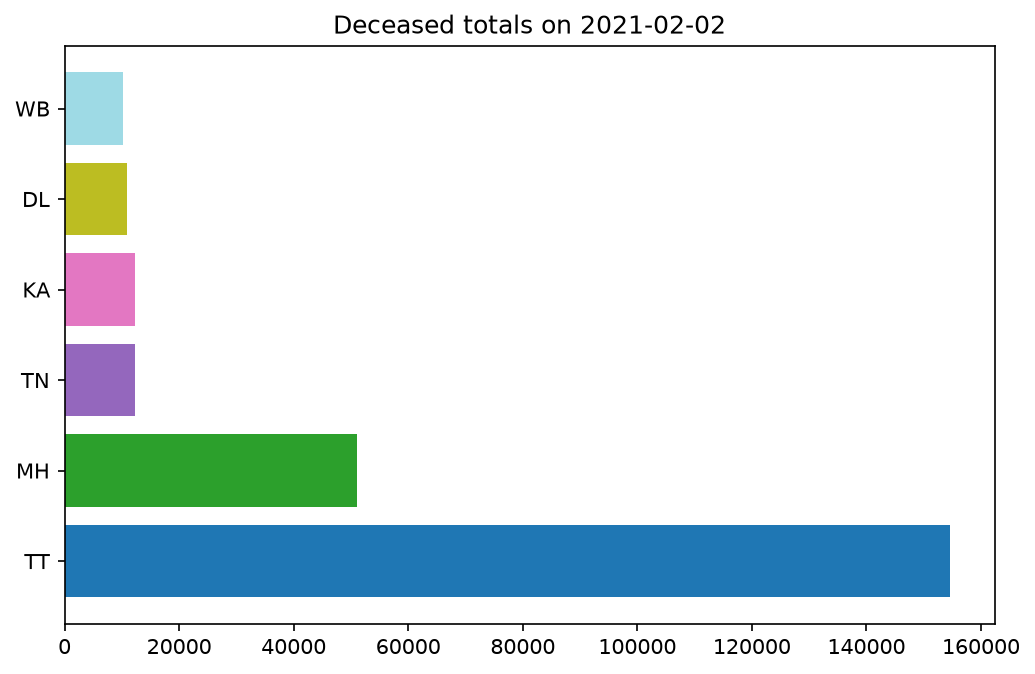

In [9]:
snapshot = df3.loc[current_date].sort_values(ascending=False).head(TOP_N)
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
ax.barh(snapshot.index, snapshot.values, color=plt.cm.tab20(np.linspace(0, 1, TOP_N)))
ax.set_title(f"{METRIC.title()} totals on {current_date.date()}")

def nice_axes(ax):
    ax.set_facecolor('.8')
    ax.tick_params(labelsize=8, length=0)
    ax.grid(True, axis='x', color='white')
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)

## Arrange, rank, and interpolate the data

In [10]:
df3 = df3.fillna(0)
df3.tail()

,AN,AP,AR,AS,BR,CH,CT,DL,DN,GA,...,RJ,SK,TG,TN,TR,TT,UN,UP,UT,WB
2021-01-29,62,7152,56,1081,1495,334,3689,10841,2,766,...,2765,133,1596,12345,388,154184,0,8646,1642,10155
2021-01-30,62,7153,56,1082,1499,334,3698,10849,2,766,...,2766,133,1598,12350,388,154312,0,8650,1643,10164
2021-01-31,62,7153,56,1082,1501,334,3701,10853,2,768,...,2766,133,1599,12356,388,154428,0,8658,1644,10173
2021-02-01,62,7154,56,1083,1503,334,3706,10856,2,768,...,2766,133,1601,12363,388,154522,0,8662,1648,10179
2021-02-02,62,7156,56,1083,1507,335,3711,10858,2,768,...,2768,135,1602,12367,388,154635,0,8668,1651,10188


In [11]:
def prepare_data(data, steps=STEPS):
    expanded = data.reset_index(names="date")
    expanded.index = expanded.index * steps
    expanded = expanded.reindex(range(expanded.index[-1] + 1))
    expanded["date"] = expanded["date"].ffill()
    values = expanded.set_index("date").interpolate()
    return values, values.rank(axis=1, method="first")

df_expanded, df_rank_expanded = prepare_data(df3)
df_expanded.head()

,AN,AP,AR,AS,BR,CH,CT,DL,DN,GA,...,RJ,SK,TG,TN,TR,TT,UN,UP,UT,WB
date,,,,,,,,,,,,,,,,,,,,,
2020-01-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Animation Function

[*source*](https://medium.com/dunder-data/create-a-bar-chart-race-animation-in-python-with-matplotlib-477ed1590096)

In [12]:
def init():
    ax.clear()
    nice_axes(ax)
    ax.set_ylim(0.5, TOP_N + 0.5)

def update(i):
    ax.clear()
    nice_axes(ax)
    frame = pd.DataFrame({"rank": df_rank_expanded.iloc[i], "value": df_expanded.iloc[i]})
    frame = frame[frame["rank"] <= TOP_N].sort_values("rank")
    ax.barh(frame["rank"], frame["value"], color=plt.cm.tab20(np.linspace(0, 1, len(frame))))
    ax.set_yticks(frame["rank"], frame.index)
    date_str = df_expanded.index[i]
    ax.set_title(f"{METRIC.title()} totals — {date_str:%Y-%m-%d}", fontsize="smaller")
    
fig = plt.Figure(figsize=(5, 5), dpi=300)
ax = fig.add_subplot()
anim = FuncAnimation(fig=fig, func=update, init_func=init, frames=len(df_expanded), 
                     interval=100, repeat=False)

In [13]:
print("Animation prepared. Run HTML(anim.to_jshtml()) in a new cell to render it inline.")

Animation prepared. Run HTML(anim.to_jshtml()) in a new cell to render it inline.


## Saving the animation

Use a writer installed on your system, for example `anim.save("covid19.mp4")`.

In [14]:
#anim.save('~/Downloads/covid19.mp4')

## Resources

[Guide to create animated bar charts](https://medium.com/dunder-data/create-a-bar-chart-race-animation-in-python-with-matplotlib-477ed1590096)